### Part 1
I Chose the PokerHand dataset. \
https://archive.ics.uci.edu/dataset/158/poker+hand 

### Part 2: Preprocess the Data 


In [65]:
import pandas as pd

# Creating column names for the 10 features plus label
columns = ["S1", "R1", "S2", "R2", "S3", "R3", "S4", "R4", "S5", "R5", "handType"]

# Load the CSV file (no header in the file)
pokerDF = pd.read_csv("poker-hand-testing.data", names=columns)

# print(pokerDF.head())
print(pokerDF["handType"].value_counts())  # Show class distribution


# Add string version for plots or summary tables
handLabels = {
    0: "Nothing", 1: "One Pair", 2: "Two Pair", 3: "Three of a Kind", 4: "Straight",
    5: "Flush", 6: "Full House", 7: "Four of a Kind", 8: "Straight Flush", 9: "Royal Flush"
}
pokerDF['handName'] = pokerDF['handType'].map(handLabels)

print(pokerDF.head())
# print(pokerDF["handName"].value_count())



handType
0    501209
1    422498
2     47622
3     21121
4      3885
5      1996
6      1424
7       230
8        12
9         3
Name: count, dtype: int64
   S1  R1  S2  R2  S3  R3  S4  R4  S5  R5  handType  handName
0   1   1   1  13   2   4   2   3   1  12         0   Nothing
1   3  12   3   2   3  11   4   5   2   5         1  One Pair
2   1   9   4   6   1   4   3   2   3   9         1  One Pair
3   1   4   3  13   2  13   2   1   3   6         1  One Pair
4   3  10   2   7   1   2   2  11   4   9         0   Nothing


In [66]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold
import seaborn as sns

X = pokerDF.iloc[:, :-2]

# Use int for model
Y = pokerDF['handType']

XTrain, XTest, YTrain, YTest = train_test_split ( X,Y, test_size=.2, stratify=Y, random_state=42)

### Part 3: Train the Models

Using scikit-learn or statsmodels:
Train the four models listed above

In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

#StandardScaler standardizes the suit/rank value features - transforms each feature to have a mean of 0 and std of 1
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
    max_iter=3000, 
    class_weight='balanced', 
    solver='saga'
)
)
#scales and trains
model.fit(XTrain, YTrain)
YPrediction = model.predict(XTest)


print("Logistic Regression Accuracy:", accuracy_score(YTest, YPrediction))
print("Classification Report:\n", classification_report(YTest, YPrediction))
# print("Confusion Matrix:\n", confusion_matrix(YTest, YPrediction))



Logistic Regression Accuracy: 0.17165
Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.23      0.31    100242
           1       0.42      0.13      0.19     84500
           2       0.05      0.05      0.05      9524
           3       0.02      0.13      0.04      4224
           4       0.00      0.01      0.00       777
           5       0.00      0.04      0.00       399
           6       0.00      0.01      0.00       285
           7       0.00      0.17      0.00        46
           8       0.00      1.00      0.00         2
           9       0.00      0.00      0.00         1

    accuracy                           0.17    200000
   macro avg       0.10      0.18      0.06    200000
weighted avg       0.42      0.17      0.24    200000



/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


The overall Accuracy for the Logistic Regression was 17%. Which changes each time I run it of course. According to the macro avg the the LR isn't caring about the rarer classes/hands, the overall performance given by the weightclass doesn't seem to be to hot either. The f1 score of "having nothing"  as well as a "one pair" is highly weighted compared to the rest of the classes. The predicitive power for classes 0-6 we visbible but the predictive power for 7-8 was practicallly non existenet. Considering that there were instances of 7-9 even though it was just 3 instances, tell me that although this isn't very accurate it's still interesting to see because the chance of getting a Royal flush for instance should be incredibly low, lower than 1/5002. The probablity of getting different hands shouldn't be represented by a logistic regression so I think it's time to move on.

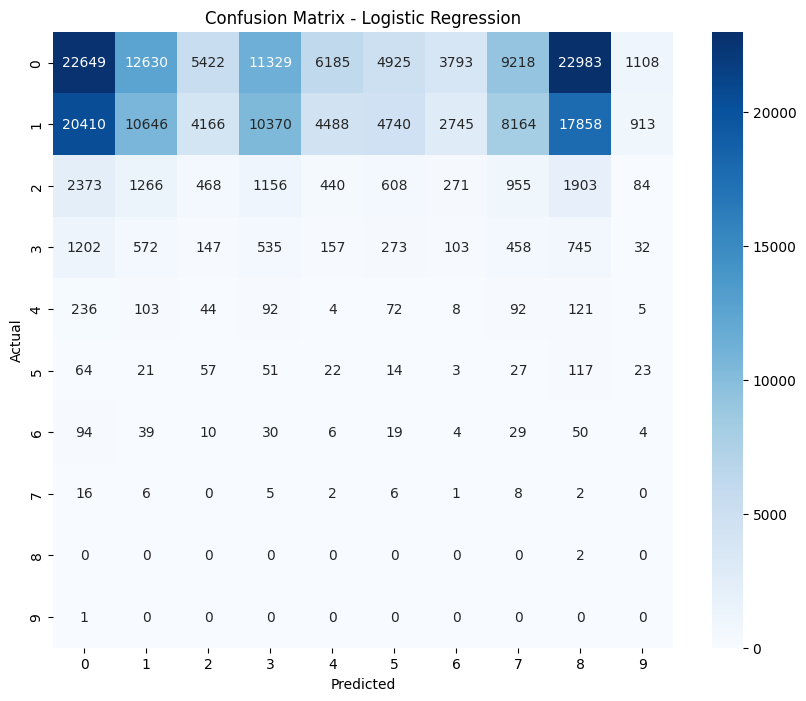

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(YTest, YPrediction)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Looking at the confusion matrix it a appears that the model works much better on class 0 and 1, but still even in these classes... had a pretty inaccurate prediction rate. Class 0 had 600 accurate predictions out of ~2500 instances.

Decision Tree Accuracy: 0.573955
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.87      0.69    100242
           1       0.56      0.33      0.41     84500
           2       0.46      0.01      0.03      9524
           3       0.92      0.06      0.11      4224
           4       0.18      0.01      0.01       777
           5       1.00      0.09      0.16       399
           6       0.85      0.04      0.07       285
           7       1.00      0.09      0.16        46
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1

    accuracy                           0.57    200000
   macro avg       0.56      0.15      0.16    200000
weighted avg       0.57      0.57      0.53    200000



/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

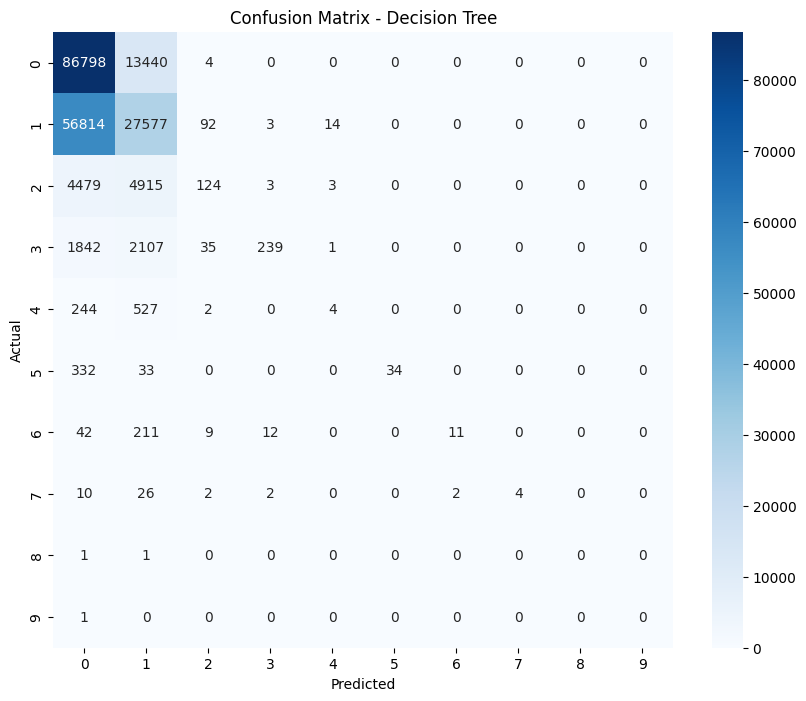

In [69]:
# from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

#intitalize the model 
treeModel = DecisionTreeClassifier(random_state = 42, max_depth=10)
#train it directly on unscaled data
treeModel.fit(XTrain,YTrain)
#predict on set
treePrediction = treeModel.predict(XTest)


print("Decision Tree Accuracy:", accuracy_score(YTest, treePrediction))
print("Classification Report:\n", classification_report(YTest, treePrediction))
# print("Confusion Matrix:\n", confusion_matrix(YTest, treePrediction))
cm = confusion_matrix(YTest, treePrediction)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

The accuracy of the decision tree was much higher! We see better precision for 0-3 classes. However we are not getting recall for rarer classes. The macro score is still very low, reflecting that rarer classes are still being ignored. The weighted score reflects that the tree is doing better on the majority classes. The confusion matrix show that the model is what I believe to be very good at predicting "nothing" and "One Pair" hands, after that it's not doing well. Class 0 and 1 are about 90% of the data so maybe there isn't enough data do do clean splits for the other classes.

increasing depth improved accuracy

/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least

K=10: 0.5640
KNN Accuracy: 0.56198
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.69      0.64    100242
           1       0.51      0.51      0.51     84500
           2       0.23      0.02      0.04      9524
           3       0.22      0.01      0.03      4224
           4       0.15      0.00      0.01       777
           5       0.98      0.63      0.77       399
           6       0.33      0.01      0.01       285
           7       0.00      0.00      0.00        46
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         1

    accuracy                           0.56    200000
   macro avg       0.30      0.19      0.20    200000
weighted avg       0.54      0.56      0.54    200000



/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/jakobwest/UtahMSD/CS6017/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

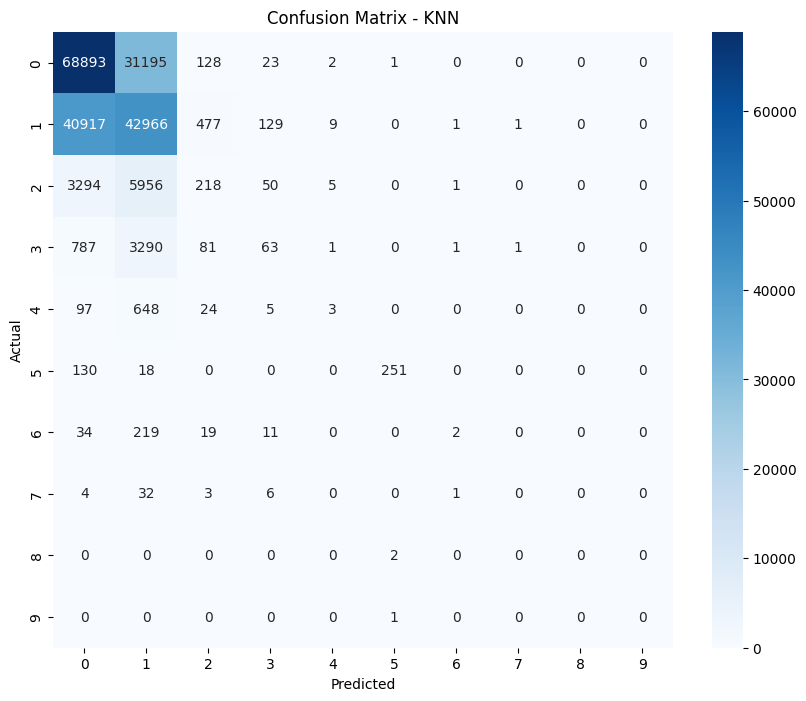

In [70]:
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

bestK = 1
bestScore = 0

from sklearn.model_selection import cross_val_score
for k in range(1, 11):
    knnModel = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    score = cross_val_score(knnModel, X, Y, cv=5, scoring='accuracy').mean()
    

    if score > bestScore:
        bestK = k
        bestScore = score

print(f"K={bestK}: {bestScore:.4f}")
knnModel = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=bestK, weights='distance')  
)
knnModel.fit(XTrain, YTrain)
knnPrediction = knnModel.predict(XTest)
print("KNN Accuracy:", accuracy_score(YTest, knnPrediction))
print("Classification Report:\n", classification_report(YTest, knnPrediction))
# print("Confusion Matrix:\n", confusion_matrix(YTest, knnPrediction))
cm = confusion_matrix(YTest, knnPrediction)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

This results of this classification experiment were very close to the Decision Tree results. The accuracy was ~51%, and the precision and recall were pretty good for classes  0 and 1. Also the macro score is still low and the weighted avg score was arlight, rare classes are still being ignored a bit. Classes 7-9 are not being predicted at all. The use weight= distance slightly improved prediction but not by much.

In [ ]:
from sklearn.feature_selection import SelectKBest, SelectPercentile
from sklearn.feature_selection import chi2, f_classif
from sklearn.svm import SVC

svmModel = make_pipeline(
    StandardScaler(),
    # SVC(kernel='rbf', C=1.0,class_weight='balanced')  
    #SVC(kernel='rbf', C=1.0)
    #  less overfitting
    SVC(kernel='rbf', C=.5,class_weight='balanced') 
)

svmModel.fit(XTrain, YTrain)
svmPrediction = svmModel.predict(XTest)
print("SVM Accuracy:", accuracy_score(YTest, svmPrediction))
print("Classification Report:\n", classification_report(YTest, svmPrediction))
# print("Confusion Matrix:\n", confusion_matrix(YTest, svmPrediction))
cm = confusion_matrix(YTest, svmPrediction)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()




Although overall accuracy is lower than the other models we got some recall in the middle classes, still there was no recall for rarest cases which is okay because Full House, Four of a Kind, and Straight Flush classses are very rare for 5 thousand poker hands. Still the macro and wieghted scores were low, but this time, presented by our cnfusion matrix there was accurate prediction more middle rarety classes, for example, the flush was predicted to be a flush and was actually a flush 7 times out of the 11 instances, the weight for the most common classes like Nothing hands and One Pair hands was relatively worse than the other models besides the logistical regression.

### Part 5 Reflect

1. Which model performed best overall and why?

Answer: Among the four models, the Decision Tree Classifier performed best overall in terms of accuracy and class  balance. It was able to capture the structure of common hands while also recognizing less frequent ones.

3. Which model was easiest/hardest to interpret?

Answer: Among the four models, the Logistic Regression was the hardest to interpret for two reasons. The first reason was that it was the first classifer I was using so I didn't really know what I should get, but it helped me realize what was going on with my data too. The second reason was that the confusion matrix seems randomly particular, why would the 'Full House' class have soooo many predictions? Before this was represented I didn't use class weight="balanced" but this result in the model only predicting "Nothing" hands, and the accuracy was still lower than other classification models. The easiest was was the Decision Tree the confusion tree really illustrates that although there is variety the first classes 0 and 1 are where most of the instances reside for the trained data, and that makes sense.

4. Which model do you think would scale well with more data?

Answer: I think that Decision Tree classifiers would would scale the most with data because the splits for each level of the tree would become more accurate.  

5. What challenges did you face while working with the dataset?

Answer: The biggest challenge in this dataset was the extreme class imbalance, which caused the models to ignore rare but important classes. Techniques like class_weight='balanced' helped alittle but the lack of training examples limited recall.